
---

# ***`Random Forest Beginings`***

---

In [17]:
import random
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

import warnings
warnings.filterwarnings('ignore')

In [ ]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.974753,-2.212196,1.680070,-0.275217,0.023746,0
1,-0.017150,-0.340711,2.383906,0.124991,-0.035734,0
2,1.658855,-0.038712,-1.368874,1.604732,-0.154225,1
3,1.287229,1.539725,1.197005,-0.779756,-3.716914,1
4,1.269755,1.137073,0.020051,-2.674899,3.397029,0


In [4]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [5]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [7]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [9]:
df1 = combined_sampling(df,0.5,0.5)

In [10]:
df2 = combined_sampling(df,0.5,0.5)

In [11]:
df3 = combined_sampling(df,0.5,0.5)

In [12]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col5', 'col4', 'target'], dtype='object')
Index(['col3', 'col5', 'target'], dtype='object')
Index(['col1', 'col5', 'target'], dtype='object')


In [13]:
df3

,col1,col5,target
61,-1.029174,1.196745,0
28,-1.650513,-0.318333,1
32,1.231973,2.525330,0
15,-0.934767,-0.249993,1
23,-3.315754,-0.600547,0
48,-0.619086,1.286442,0
40,-1.513245,2.730510,0
93,-0.009793,3.792525,0
20,-1.942241,0.954937,1
87,0.006178,2.303282,0


In [15]:
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [16]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

[Text(0.375, 0.9285714285714286, 'x[0] <= 1.206\ngini = 0.497\nsamples = 50\nvalue = [23, 27]'),
 Text(0.25, 0.7857142857142857, 'x[1] <= -0.603\ngini = 0.426\nsamples = 39\nvalue = [12, 27]'),
 Text(0.3125, 0.8571428571428572, 'True  '),
 Text(0.125, 0.6428571428571429, 'gini = 0.0\nsamples = 13\nvalue = [0, 13]'),
 Text(0.375, 0.6428571428571429, 'x[0] <= -1.232\ngini = 0.497\nsamples = 26\nvalue = [12, 14]'),
 Text(0.25, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.5, 0.5, 'x[0] <= -0.757\ngini = 0.49\nsamples = 21\nvalue = [12, 9]'),
 Text(0.25, 0.35714285714285715, 'x[1] <= 0.069\ngini = 0.198\nsamples = 9\nvalue = [8, 1]'),
 Text(0.125, 0.21428571428571427, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.375, 0.21428571428571427, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.75, 0.35714285714285715, 'x[1] <= 0.18\ngini = 0.444\nsamples = 12\nvalue = [4, 8]'),
 Text(0.625, 0.21428571428571427, 'x[0] <= -0.287\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text

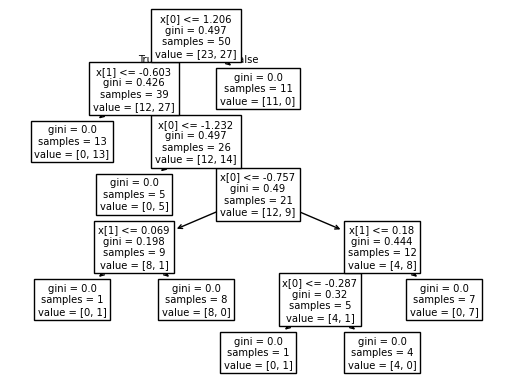

In [18]:
plot_tree(clf1)

[Text(0.375, 0.9, 'x[0] <= -0.251\ngini = 0.493\nsamples = 50\nvalue = [28.0, 22.0]'),
 Text(0.16666666666666666, 0.7, 'x[1] <= 1.37\ngini = 0.266\nsamples = 19\nvalue = [3, 16]'),
 Text(0.2708333333333333, 0.8, 'True  '),
 Text(0.08333333333333333, 0.5, 'gini = 0.0\nsamples = 16\nvalue = [0, 16]'),
 Text(0.25, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.5833333333333334, 0.7, 'x[1] <= -1.323\ngini = 0.312\nsamples = 31\nvalue = [25, 6]'),
 Text(0.4791666666666667, 0.8, '  False'),
 Text(0.4166666666666667, 0.5, 'x[0] <= 1.709\ngini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.3333333333333333, 0.3, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.5, 0.3, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.75, 0.5, 'x[1] <= 2.416\ngini = 0.083\nsamples = 23\nvalue = [22, 1]'),
 Text(0.6666666666666666, 0.3, 'gini = 0.0\nsamples = 20\nvalue = [20, 0]'),
 Text(0.8333333333333334, 0.3, 'x[1] <= 2.476\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.75, 0.1, 'gini =

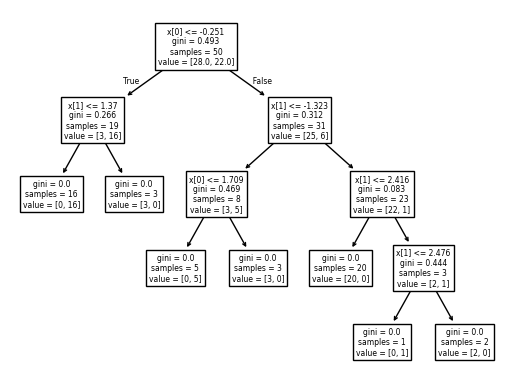

In [19]:
plot_tree(clf2)

[Text(0.5769230769230769, 0.9166666666666666, 'x[1] <= -0.184\ngini = 0.48\nsamples = 50\nvalue = [30, 20]'),
 Text(0.3076923076923077, 0.75, 'x[0] <= -2.236\ngini = 0.363\nsamples = 21\nvalue = [5, 16]'),
 Text(0.4423076923076923, 0.8333333333333333, 'True  '),
 Text(0.15384615384615385, 0.5833333333333334, 'x[1] <= -2.694\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.07692307692307693, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.23076923076923078, 0.4166666666666667, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.46153846153846156, 0.5833333333333334, 'x[0] <= -1.71\ngini = 0.117\nsamples = 16\nvalue = [1, 15]'),
 Text(0.38461538461538464, 0.4166666666666667, 'x[0] <= -1.947\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.3076923076923077, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.46153846153846156, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5384615384615384, 0.4166666666666667, 'gini = 0.0\nsamples = 12\nva

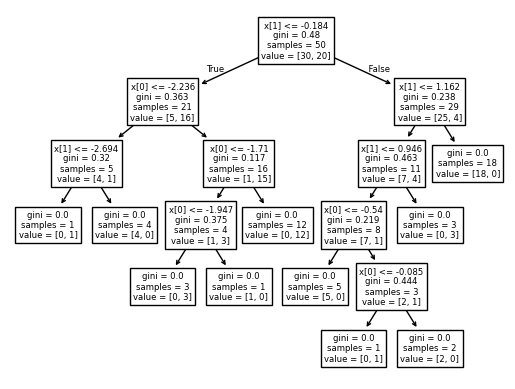

In [20]:
plot_tree(clf3)

In [21]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

array([1])

In [22]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

array([1])

In [23]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

array([0])

In [24]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
99,-4.163803,0.778506,0.779729,-3.023549,-0.802323,1
77,0.379976,-1.865920,1.620633,-0.520341,0.690414,0
41,-3.289931,1.810681,0.876696,-3.536825,-1.878755,1
93,-0.009793,2.497031,-0.172823,-2.686269,3.792525,0
57,-1.872101,-2.038436,0.927086,0.437245,-1.018605,0
77,0.379976,-1.865920,1.620633,-0.520341,0.690414,0
13,-3.144372,-1.876409,-0.172096,-1.362972,0.355460,0
37,2.125479,1.098003,-0.964612,0.622650,-2.219245,1
15,-0.934767,1.644915,-2.164736,-1.239338,-0.249993,1
12,0.928321,-0.272604,-2.760289,1.617385,0.206985,1


---